In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv("../data/annonces_enrichies_int.csv", sep=";")
print(f'Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
df.head()

Dimensions : 95,202 lignes × 24 colonnes


,id,type_bien,surface,loyer,nb_pieces,code_postal,ville,quartier,etage,etage_maxi,...,balcon,terrasse,parking,charges,montant_charges,web_source,dates,nb_annonces,loyer_moyen,loyer_m2_moyen
0,1,Appartement,64,2900,3,75002,Paris,NaN,0,0,...,NaN,NaN,NaN,NaN,0,Leboncoin,20250415,229,2746,64
1,2,Studio,35,2615,1,75016,Paris 16eme,Auteuil Sud,7,7,...,NaN,True,NaN,True,0,SeLoger,20250415,618,3344,44
2,3,appartement,60,1395,3,95870,Bezons,Agriculture,0,0,...,NaN,NaN,NaN,True,0,BienIci,20250415,78,1103,25
3,4,Appartement,90,4940,3,75002,Paris 2eme,Sentier-Bonne Nouvelle,2,6,...,NaN,NaN,NaN,True,0,SeLoger,20250415,229,2746,64
4,5,Appartement,58,1800,3,75016,Paris,NaN,0,0,...,NaN,NaN,NaN,NaN,0,Leboncoin,20250415,618,3344,44


In [8]:
# Types de colonnes et valeurs manquantes
missing = df.isnull().sum()
pct     = (missing / len(df) * 100).round(1)
resume  = pd.DataFrame({'dtype': df.dtypes, 'nb_nulls': missing, 'pct_nulls': pct})
resume.sort_values('pct_nulls', ascending=False)

,dtype,nb_nulls,pct_nulls
chauffage_type,object,94350,99.1
chauffage_mode,object,94274,99.0
terrasse,object,90493,95.1
ascenseur,object,88376,92.8
balcon,object,88040,92.5
parking,object,86317,90.7
meuble,object,72650,76.3
quartier,object,42808,45.0
charges,object,29089,30.6
ville,object,10237,10.8


In [9]:
# Statistiques descriptives des colonnes numériques
df[['loyer', 'surface', 'nb_pieces', 'etage', 'loyer_m2_moyen']].describe().round(1)

,loyer,surface,nb_pieces,etage,loyer_m2_moyen
count,95202.0,95202.0,95202.0,95202.0,95202.0
mean,997.7,48.8,2.3,0.8,21.9
std,1522.5,51.1,1.4,8.2,9.6
min,0.0,0.0,0.0,0.0,0.0
25%,535.0,25.0,1.0,0.0,15.0
50%,730.0,42.0,2.0,0.0,19.0
75%,1095.0,65.0,3.0,1.0,25.0
max,190000.0,8003.0,38.0,1990.0,76.0


## 2. Analyse exploratoire (EDA)

### 2.1 Distribution des loyers

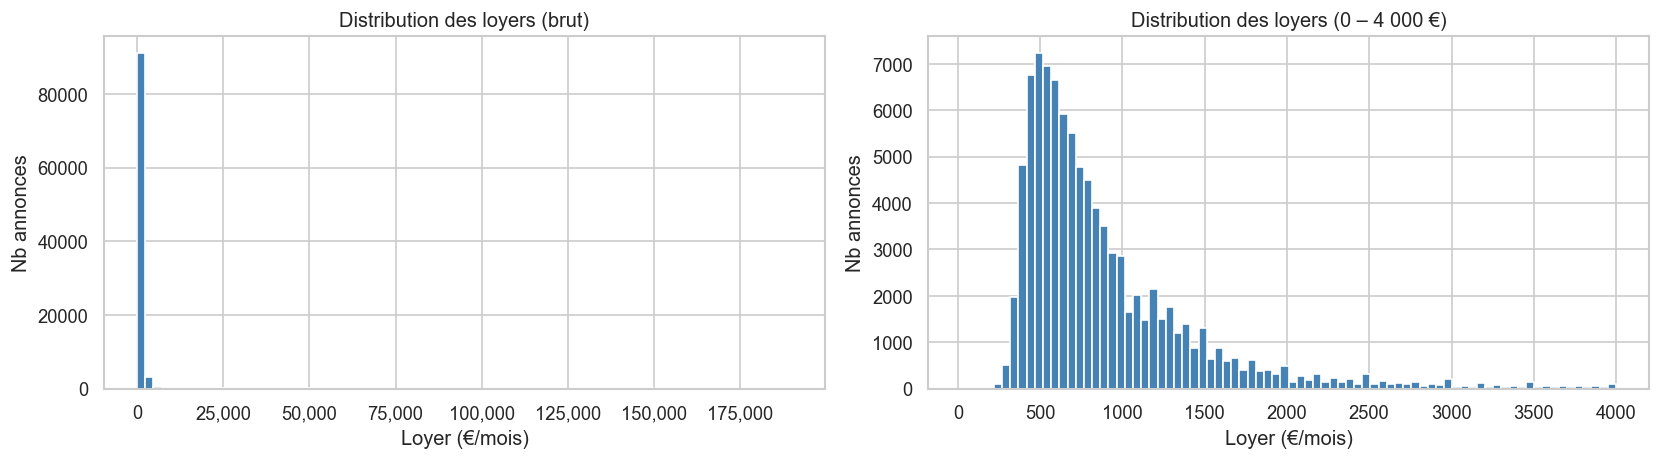

Médiane : 730 €  |  Moyenne : 998 €
Min : 0 €  |  Max : 190,000 €


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogramme brut (tout l'échantillon)
axes[0].hist(df['loyer'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution des loyers (brut)')
axes[0].set_xlabel('Loyer (€/mois)')
axes[0].set_ylabel('Nb annonces')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Zoom sans outliers extrêmes
df_zoom = df[(df['loyer'] > 0) & (df['loyer'] <= 4000)]
axes[1].hist(df_zoom['loyer'], bins=80, color='steelblue', edgecolor='white')
axes[1].set_title('Distribution des loyers (0 – 4 000 €)')
axes[1].set_xlabel('Loyer (€/mois)')
axes[1].set_ylabel('Nb annonces')

plt.tight_layout()
plt.show()

print(f"Médiane : {df['loyer'].median():.0f} €  |  Moyenne : {df['loyer'].mean():.0f} €")
print(f"Min : {df['loyer'].min()} €  |  Max : {df['loyer'].max():,} €")

### 2.2 Distribution des surfaces

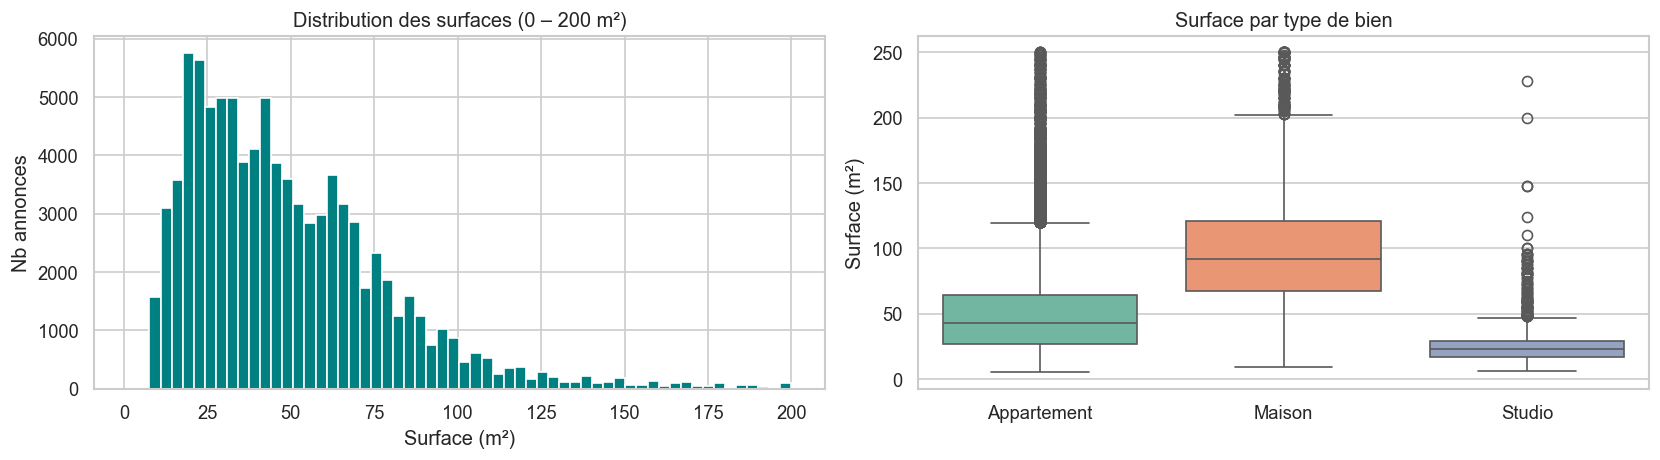

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_surf = df[(df['surface'] > 0) & (df['surface'] <= 200)]

axes[0].hist(df_surf['surface'], bins=60, color='teal', edgecolor='white')
axes[0].set_title('Distribution des surfaces (0 – 200 m²)')
axes[0].set_xlabel('Surface (m²)')
axes[0].set_ylabel('Nb annonces')

# Boxplot par type de bien
df_box = df[df['surface'].between(5, 250)].copy()
df_box['type_clean'] = df_box['type_bien'].str.strip().str.capitalize()
order = df_box['type_clean'].value_counts().index[:4]
sns.boxplot(data=df_box[df_box['type_clean'].isin(order)],
            x='type_clean', y='surface', order=order,
            ax=axes[1], palette='Set2')
axes[1].set_title('Surface par type de bien')
axes[1].set_xlabel('')
axes[1].set_ylabel('Surface (m²)')

plt.tight_layout()
plt.show()

### 2.3 Loyers par type de bien

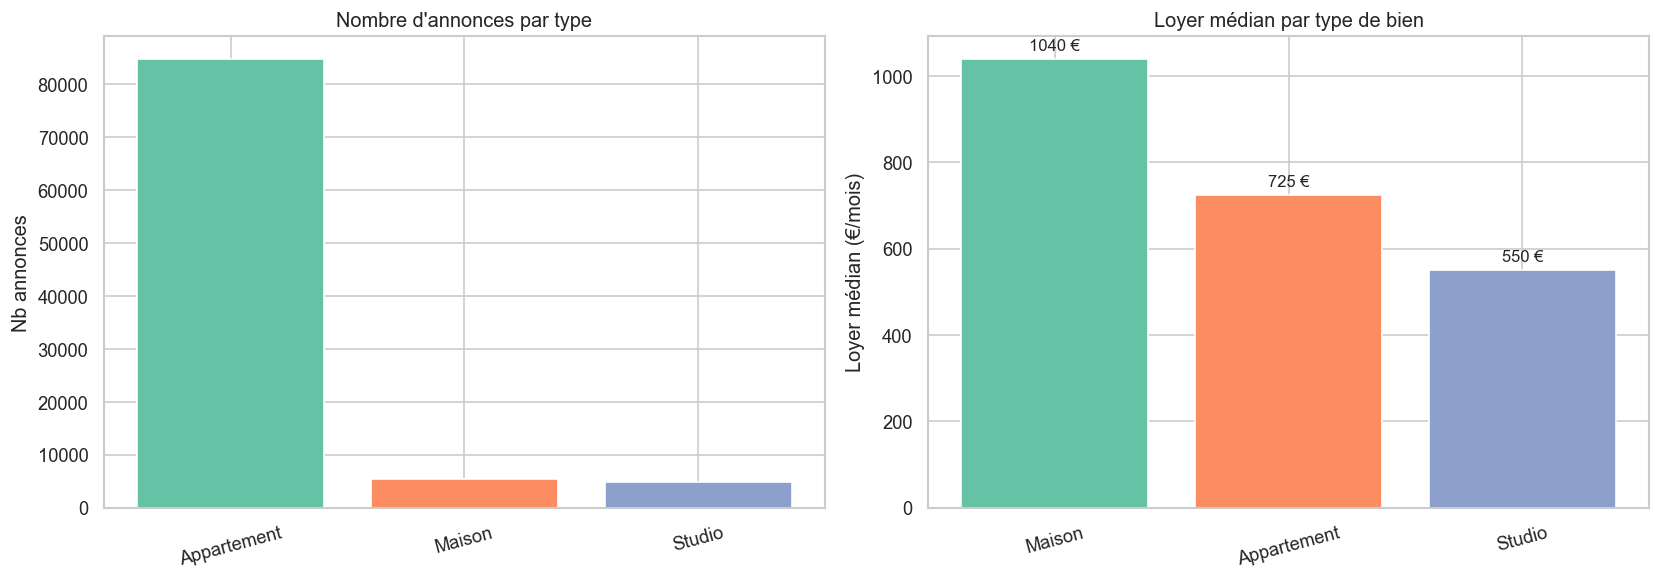

In [12]:
df['type_clean'] = df['type_bien'].str.strip().str.capitalize()
df_valid = df[(df['loyer'] > 0) & (df['loyer'] <= 5000)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Nombre d'annonces par type
counts = df['type_clean'].value_counts()
axes[0].bar(counts.index, counts.values, color=sns.color_palette('Set2', len(counts)))
axes[0].set_title("Nombre d'annonces par type")
axes[0].set_ylabel('Nb annonces')
axes[0].tick_params(axis='x', rotation=15)

# Loyer médian par type
medians = df_valid.groupby('type_clean')['loyer'].median().sort_values(ascending=False)
axes[1].bar(medians.index, medians.values, color=sns.color_palette('Set2', len(medians)))
axes[1].set_title('Loyer médian par type de bien')
axes[1].set_ylabel('Loyer médian (€/mois)')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(medians.values):
    axes[1].text(i, v + 20, f'{v:.0f} €', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### 2.4 Loyers par source de données

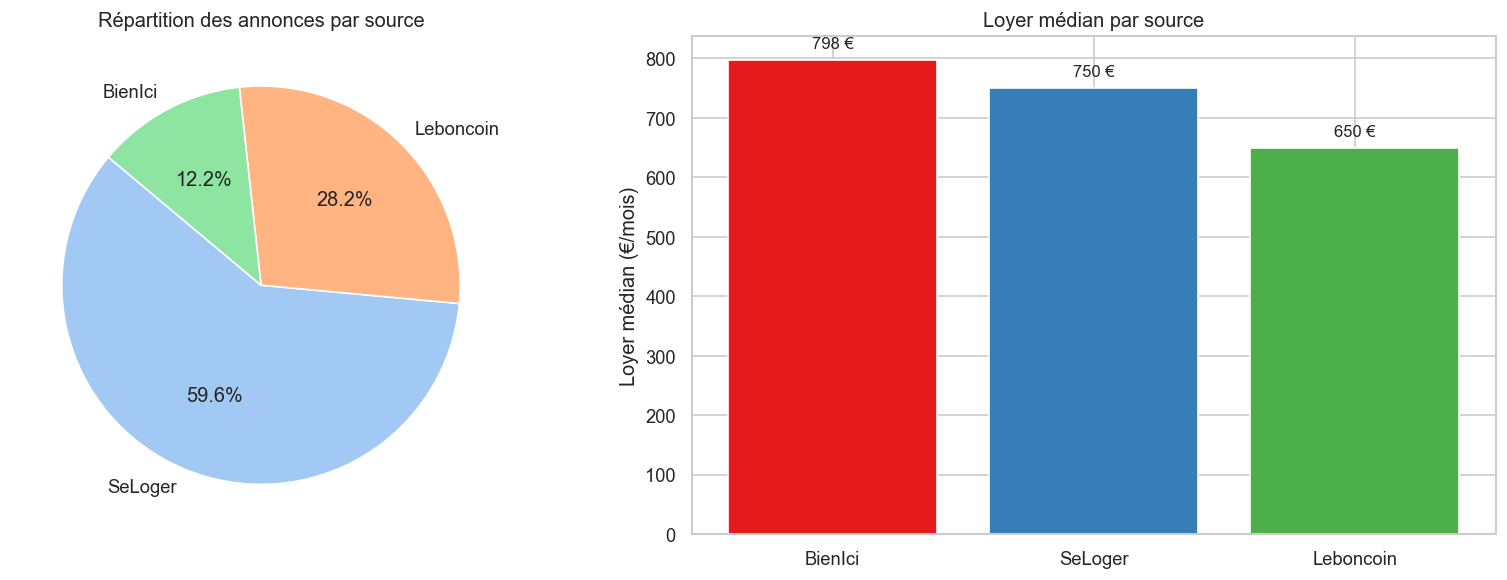

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Répartition des sources
src = df['web_source'].value_counts()
axes[0].pie(src.values, labels=src.index, autopct='%1.1f%%',
            colors=sns.color_palette('pastel')[:len(src)], startangle=140)
axes[0].set_title('Répartition des annonces par source')

# Loyer médian par source
df_valid2 = df[(df['loyer'] > 0) & (df['loyer'] <= 5000)]
src_med = df_valid2.groupby('web_source')['loyer'].median().sort_values(ascending=False)
axes[1].bar(src_med.index, src_med.values, color=sns.color_palette('Set1', len(src_med)))
axes[1].set_title('Loyer médian par source')
axes[1].set_ylabel('Loyer médian (€/mois)')
for i, v in enumerate(src_med.values):
    axes[1].text(i, v + 20, f'{v:.0f} €', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### 2.5 Top 15 villes par loyer médian (min. 30 annonces)

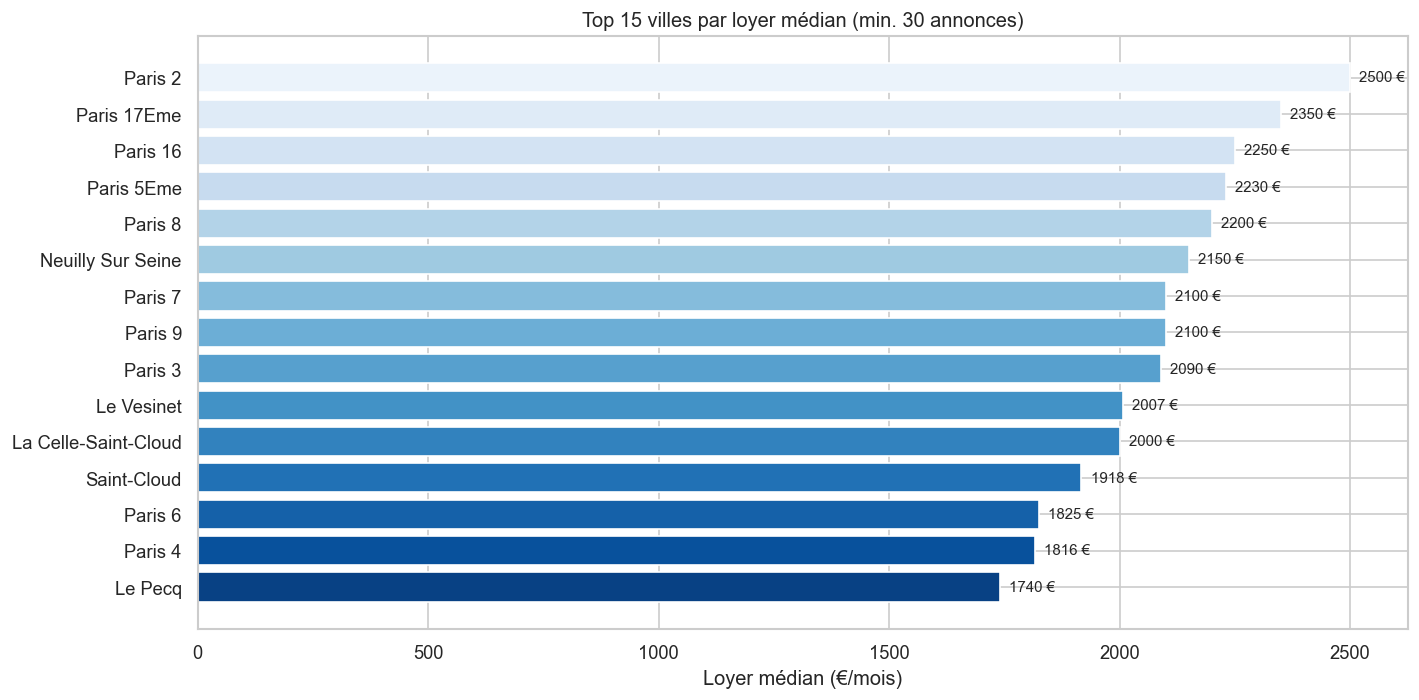

               ville  nb  med_loyer  med_m2
             Paris 2 150     2500.0    64.0
         Paris 17Eme  33     2350.0    45.0
            Paris 16 461     2250.0    44.0
          Paris 5Eme  31     2230.0    47.0
             Paris 8 322     2200.0    55.0
   Neuilly Sur Seine  76     2150.0    43.0
             Paris 7 241     2100.0    55.0
             Paris 9 161     2100.0    50.0
             Paris 3  81     2090.0    52.0
          Le Vesinet  81     2007.0    27.0
La Celle-Saint-Cloud  46     2000.0    23.0
         Saint-Cloud 120     1917.5    30.0
             Paris 6 180     1825.0    57.0
             Paris 4  82     1816.5    51.0
             Le Pecq  30     1740.5    25.0


In [14]:
df_v = df[(df['loyer'] > 0) & (df['loyer'] <= 5000) & df['ville'].notna()].copy()
df_v['ville'] = df_v['ville'].str.strip().str.title()

stats_villes = df_v.groupby('ville').agg(
    nb        = ('loyer', 'count'),
    med_loyer = ('loyer', 'median'),
    med_m2    = ('loyer_m2_moyen', 'median')
).query('nb >= 30').sort_values('med_loyer', ascending=False).head(15).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(stats_villes['ville'][::-1], stats_villes['med_loyer'][::-1],
               color=sns.color_palette('Blues_r', 15))
for bar, val in zip(bars, stats_villes['med_loyer'][::-1]):
    ax.text(val + 20, bar.get_y() + bar.get_height()/2,
            f'{val:.0f} €', va='center', fontsize=9)
ax.set_title('Top 15 villes par loyer médian (min. 30 annonces)')
ax.set_xlabel('Loyer médian (€/mois)')
plt.tight_layout()
plt.show()

print(stats_villes[['ville', 'nb', 'med_loyer', 'med_m2']].to_string(index=False))

### 2.6 Loyer vs Surface — nuage de points

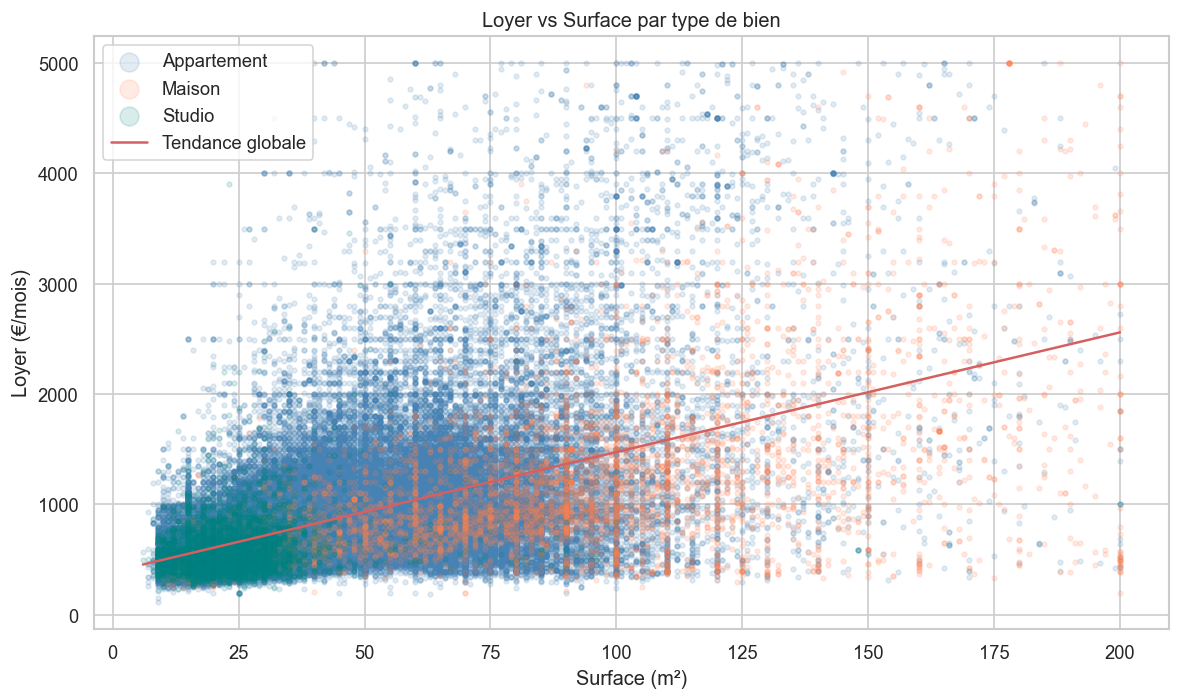

Corrélation Loyer / Surface : 0.514


In [15]:
df_sc = df[
    (df['loyer'] > 100) & (df['loyer'] <= 5000) &
    (df['surface'] > 5) & (df['surface'] <= 200)
].copy()
df_sc['type_clean'] = df_sc['type_bien'].str.strip().str.capitalize()
types_top = df_sc['type_clean'].value_counts().head(3).index
df_sc = df_sc[df_sc['type_clean'].isin(types_top)]

fig, ax = plt.subplots(figsize=(10, 6))
palette = {'Appartement': 'steelblue', 'Studio': 'teal', 'Maison': 'coral'}
for t, grp in df_sc.groupby('type_clean'):
    ax.scatter(grp['surface'], grp['loyer'],
               alpha=0.15, s=8,
               color=palette.get(t, 'gray'), label=t)

# Ligne de tendance globale
m, b = np.polyfit(df_sc['surface'], df_sc['loyer'], 1)
xs = np.linspace(df_sc['surface'].min(), df_sc['surface'].max(), 100)
ax.plot(xs, m*xs + b, 'r-', linewidth=1.5, label='Tendance globale')

ax.set_title('Loyer vs Surface par type de bien')
ax.set_xlabel('Surface (m²)')
ax.set_ylabel('Loyer (€/mois)')
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()

print(f'Corrélation Loyer / Surface : {df_sc[["loyer","surface"]].corr().iloc[0,1]:.3f}')

### 2.7 Heatmap des corrélations

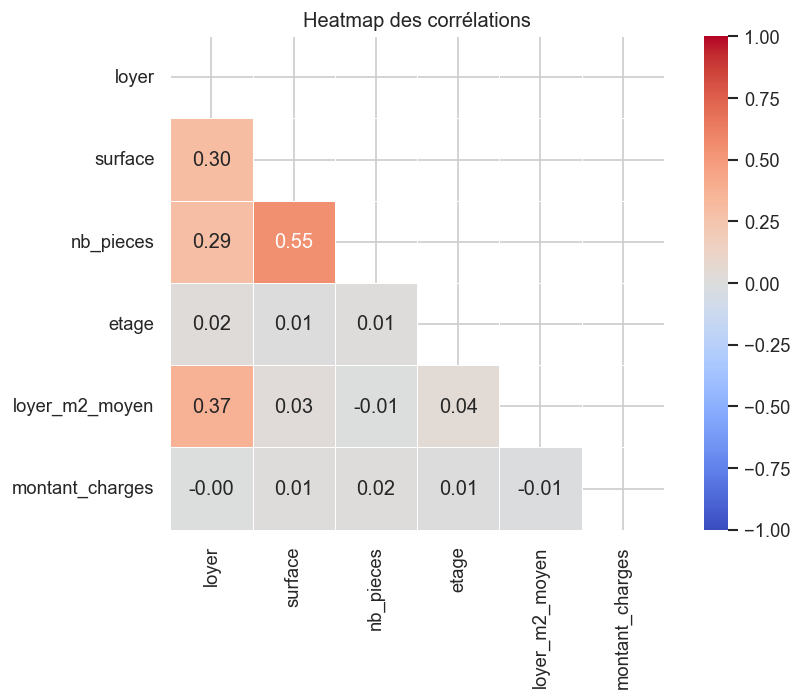

In [16]:
cols_num = ['loyer', 'surface', 'nb_pieces', 'etage', 'loyer_m2_moyen', 'montant_charges']
corr = df[cols_num].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Heatmap des corrélations')
plt.tight_layout()
plt.show()

### 2.8 Valeurs manquantes — visualisation

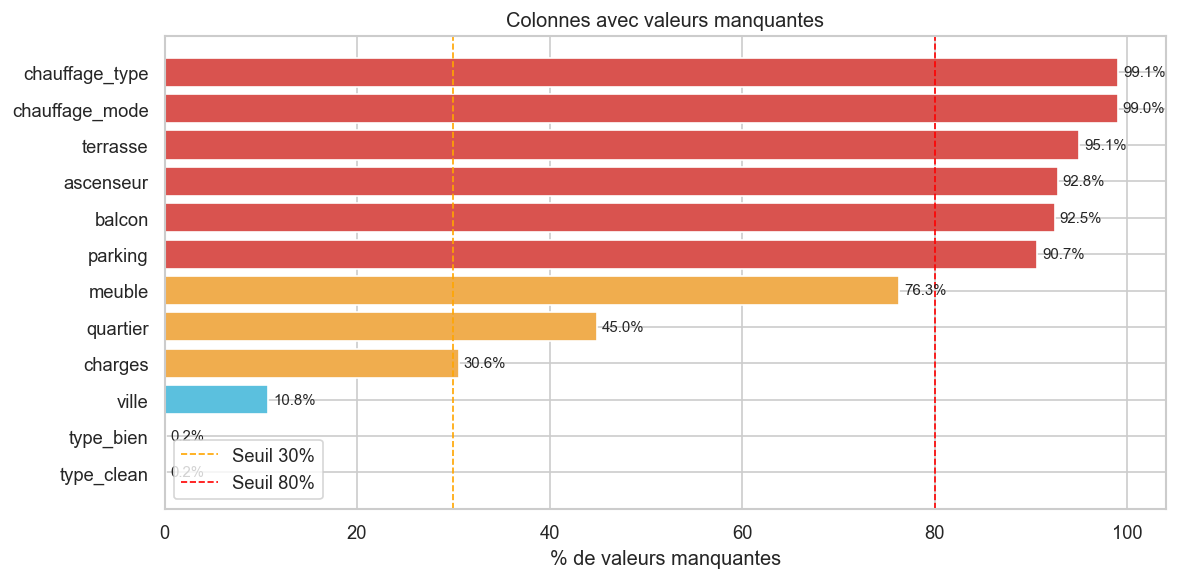

In [17]:
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=True)
missing_pct = missing_pct[missing_pct > 0]

colors = ['#d9534f' if v > 80 else '#f0ad4e' if v > 30 else '#5bc0de'
          for v in missing_pct.values]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(missing_pct.index, missing_pct.values, color=colors)
ax.axvline(30, color='orange', linestyle='--', linewidth=1, label='Seuil 30%')
ax.axvline(80, color='red',    linestyle='--', linewidth=1, label='Seuil 80%')
ax.set_xlabel('% de valeurs manquantes')
ax.set_title('Colonnes avec valeurs manquantes')
ax.legend()
for i, (col, val) in enumerate(zip(missing_pct.index, missing_pct.values)):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Détection des anomalies

Avant de nettoyer, on quantifie précisément ce qui pose problème.

In [18]:
print('━━ ANOMALIES DÉTECTÉES ━━')
print(f"type_bien nul            : {df['type_bien'].isna().sum():>6} lignes")
print(f"Doublons type_bien casse : {(df['type_clean'] != df['type_bien'].str.strip()).sum():>6} lignes")
print(f"Loyer = 0                : {(df['loyer'] == 0).sum():>6} lignes")
print(f"Loyer > 10 000 €         : {(df['loyer'] > 10000).sum():>6} lignes")
print(f"Surface = 0              : {(df['surface'] == 0).sum():>6} lignes")
print(f"Surface > 500 m²         : {(df['surface'] > 500).sum():>6} lignes")
print(f"chauffage_mode nul       : {df['chauffage_mode'].isna().sum():>6} ({df['chauffage_mode'].isna().mean()*100:.0f}%)")
print(f"chauffage_type nul       : {df['chauffage_type'].isna().sum():>6} ({df['chauffage_type'].isna().mean()*100:.0f}%)")
print()

# Loyer/m² pour les lignes avec surface > 0
df_tmp = df[df['surface'] > 0].copy()
df_tmp['lm2'] = df_tmp['loyer'] / df_tmp['surface']
print(f"Loyer/m² < 3 €           : {(df_tmp['lm2'] < 3).sum():>6} lignes")
print(f"Loyer/m² > 100 €         : {(df_tmp['lm2'] > 100).sum():>6} lignes")

# Exemples d'outliers loyer
print('\n── Exemples loyers > 10 000 € ──')
display(df[df['loyer'] > 10000][['type_bien','surface','loyer','ville','web_source']].head(5))

━━ ANOMALIES DÉTECTÉES ━━
type_bien nul            :    146 lignes
Doublons type_bien casse :  11847 lignes
Loyer = 0                :      6 lignes
Loyer > 10 000 €         :    292 lignes
Surface = 0              :   3560 lignes
Surface > 500 m²         :     23 lignes
chauffage_mode nul       :  94274 (99%)
chauffage_type nul       :  94350 (99%)

Loyer/m² < 3 €           :    181 lignes
Loyer/m² > 100 €         :    196 lignes

── Exemples loyers > 10 000 € ──


,type_bien,surface,loyer,ville,web_source
141,Appartement,34,50000,Marseille,Leboncoin
708,Appartement,178,12000,Paris 15eme,SeLoger
1021,Appartement,219,12000,NaN,SeLoger
1815,Appartement,236,22000,Paris 16eme,SeLoger
1854,Appartement,331,14700,NaN,SeLoger


## 4. Nettoyage

On applique toutes les corrections identifiées lors de l'EDA.

In [19]:
# ── 4.1 Copie de travail
df_clean = df.copy()
n_init = len(df_clean)
print(f'Début : {n_init:,} lignes')

Début : 95,202 lignes


In [20]:
# ── 4.2 Normalisation de type_bien
mapping = {
    'appartement': 'Appartement', 'APPARTEMENT': 'Appartement',
    'studio':      'Studio',
    'maison':      'Maison',
}
df_clean['type_bien'] = df_clean['type_bien'].str.strip().replace(mapping)
df_clean = df_clean[df_clean['type_bien'].notna()]
print(f"Après nettoyage type_bien : {len(df_clean):,} lignes")
print(df_clean['type_bien'].value_counts())

Après nettoyage type_bien : 95,056 lignes
type_bien
Appartement    84861
Maison          5367
Studio          4828
Name: count, dtype: int64


In [21]:
# ── 4.3 Suppression des outliers
df_clean = df_clean[df_clean['loyer'].between(50, 10_000)]
df_clean = df_clean[df_clean['surface'].between(5, 500)]

df_clean['loyer_m2_calc'] = df_clean['loyer'] / df_clean['surface']
df_clean = df_clean[df_clean['loyer_m2_calc'].between(3, 100)]

print(f"Après suppression outliers : {len(df_clean):,} lignes ({n_init - len(df_clean):,} supprimées)")

Après suppression outliers : 90,973 lignes (4,229 supprimées)


In [22]:
# ── 4.4 Normalisation des booléens → 0 / 1
def to_bool_int(series):
    return series.map(lambda x: 1 if str(x).strip().lower() in ('true', '1', 'cc') else 0)

for col in ['meuble', 'ascenseur', 'balcon', 'terrasse', 'parking', 'charges']:
    df_clean[col] = to_bool_int(df_clean[col])

print('Booléens normalisés :', df_clean[['meuble','balcon','parking','charges']].mean().round(2).to_dict())

Booléens normalisés : {'meuble': 0.24, 'balcon': 0.08, 'parking': 0.1, 'charges': 0.71}


In [23]:
# ── 4.5 Suppression des colonnes inutilisables
df_clean = df_clean.drop(columns=['chauffage_mode', 'chauffage_type'], errors='ignore')

# Nettoyage ville
df_clean['ville'] = df_clean['ville'].str.strip().str.title()

# Conversion dates
df_clean['date'] = pd.to_datetime(df_clean['dates'].astype(str), format='%Y%m%d', errors='coerce')
df_clean = df_clean.drop(columns=['dates'])

print('Colonnes finales :', list(df_clean.columns))

Colonnes finales : ['id', 'type_bien', 'surface', 'loyer', 'nb_pieces', 'code_postal', 'ville', 'quartier', 'etage', 'etage_maxi', 'meuble', 'ascenseur', 'balcon', 'terrasse', 'parking', 'charges', 'montant_charges', 'web_source', 'nb_annonces', 'loyer_moyen', 'loyer_m2_moyen', 'type_clean', 'loyer_m2_calc', 'date']


In [24]:
# ── 4.6 Feature engineering
df_clean['surface_par_piece'] = (df_clean['surface'] / df_clean['nb_pieces'].replace(0, np.nan)).round(1)

df_clean['est_paris'] = df_clean['code_postal'].astype(str).str.startswith('75').astype(int)
df_clean['est_idf']   = df_clean['code_postal'].astype(str).str.startswith(('75','77','78','91','92','93','94','95')).astype(int)

df_clean['etage_relatif'] = np.where(
    df_clean['etage_maxi'] > 0,
    (df_clean['etage'] / df_clean['etage_maxi']).clip(0, 1).round(2),
    0
)

print('Nouvelles colonnes créées : surface_par_piece, est_paris, est_idf, etage_relatif')
df_clean.head(3)

Nouvelles colonnes créées : surface_par_piece, est_paris, est_idf, etage_relatif


,id,type_bien,surface,loyer,nb_pieces,code_postal,ville,quartier,etage,etage_maxi,...,nb_annonces,loyer_moyen,loyer_m2_moyen,type_clean,loyer_m2_calc,date,surface_par_piece,est_paris,est_idf,etage_relatif
0,1,Appartement,64,2900,3,75002,Paris,NaN,0,0,...,229,2746,64,Appartement,45.312500,2025-04-15,21.3,1,1,0.0
1,2,Studio,35,2615,1,75016,Paris 16Eme,Auteuil Sud,7,7,...,618,3344,44,Studio,74.714286,2025-04-15,35.0,1,1,1.0
2,3,Appartement,60,1395,3,95870,Bezons,Agriculture,0,0,...,78,1103,25,Appartement,23.250000,2025-04-15,20.0,0,1,0.0


In [25]:
# ── Bilan final
print('━━ BILAN DU NETTOYAGE ━━')
print(f'Lignes initiales  : {n_init:>8,}')
print(f'Lignes finales    : {len(df_clean):>8,}')
print(f'Lignes supprimées : {n_init - len(df_clean):>8,}  ({(n_init - len(df_clean))/n_init*100:.1f}%)')
print(f'Colonnes finales  : {df_clean.shape[1]}')
print(f'\nValeurs manquantes restantes :')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

━━ BILAN DU NETTOYAGE ━━
Lignes initiales  :   95,202
Lignes finales    :   90,973
Lignes supprimées :    4,229  (4.4%)
Colonnes finales  : 28

Valeurs manquantes restantes :
ville                 9543
quartier             39634
surface_par_piece     1212
dtype: int64


## 5. Export des fichiers nettoyés

In [26]:
# Dataset complet nettoyé → pour le modèle ML
df_clean.to_csv('annonces_clean.csv', index=False, sep=';')
print('annonces_clean.csv exporté')

# Agrégat par code postal → pour l'API et la carte
agg = df_clean.groupby('code_postal').agg(
    nb_annonces       = ('id',            'count'),
    loyer_median      = ('loyer',         'median'),
    loyer_moyen       = ('loyer',         'mean'),
    loyer_m2_median   = ('loyer_m2_calc', 'median'),
    surface_moy       = ('surface',       'mean'),
    ville_principale  = ('ville', lambda x: x.mode()[0] if x.notna().any() else ''),
).reset_index()

for c in ['loyer_median', 'loyer_moyen', 'loyer_m2_median', 'surface_moy']:
    agg[c] = agg[c].round(1)

agg.to_csv('loyers_par_cp.csv', index=False, sep=';')
print(f' loyers_par_cp.csv exporté ({len(agg)} codes postaux)')

print('\n── Aperçu agrégat par code postal ──')
agg.sort_values('loyer_median', ascending=False).head(10)

✅ annonces_clean.csv exporté
✅ loyers_par_cp.csv exporté (1397 codes postaux)

── Aperçu agrégat par code postal ──


,code_postal,nb_annonces,loyer_median,loyer_moyen,loyer_m2_median,surface_moy,ville_principale
844,69126,1,5900.0,5900.0,17.8,332.0,Brindas
299,33115,2,4300.5,4300.5,54.3,60.5,La Teste-De-Buch
1025,78290,3,4090.0,4090.0,31.0,132.0,Croissy-Sur-Seine
89,13420,1,4000.0,4000.0,22.2,180.0,Gemenos
1042,78620,9,4000.0,3782.2,19.6,194.9,L'Etang-La-Ville
67,13122,1,3700.0,3700.0,24.7,150.0,Ventabren
1033,78400,5,3590.0,3177.4,19.1,163.2,Chatou
1003,77630,2,3350.0,3350.0,16.4,215.5,Barbizon
78,13260,1,3200.0,3200.0,43.2,74.0,Cassis
913,74250,1,2975.0,2975.0,27.3,109.0,
